In [ ]:
# =========================
# 0. SETUP Y DESCARGA
# =========================
import os, io, zipfile, random, re, collections
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

DATA_DIR = "data"
RAW_TXT = os.path.join(DATA_DIR, "spa.txt")
os.makedirs(DATA_DIR, exist_ok=True)

# Orígenes en orden de preferencia (mismo archivo spa-eng.zip de Tatoeba/ManyThings)
SOURCES = [
    ("ManyThings (oficial)", "https://www.manythings.org/anki/spa-eng.zip"),
    ("Espejo Google/TensorFlow", "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"),
]
BROWSER_HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/124.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.manythings.org/anki/",
}

def extract_spa_txt(zip_bytes):
    """Extrae 'spa.txt' del zip sin importar si está en una subcarpeta."""
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
        print("  Contenido del zip:", z.namelist())
        member = next(n for n in z.namelist() if n.endswith("spa.txt"))
        with z.open(member) as src, open(RAW_TXT, "wb") as dst:
            dst.write(src.read())

DOWNLOAD_SOURCE = None
if not os.path.exists(RAW_TXT):
    for name, url in SOURCES:
        try:
            print(f"Intentando: {name} -> {url}")
            r = requests.get(url, headers=BROWSER_HEADERS, timeout=60)
            r.raise_for_status()
            extract_spa_txt(r.content)
            DOWNLOAD_SOURCE = name
            break
        except Exception as e:
            print(f"  Falló: {e}")

    if not os.path.exists(RAW_TXT):
        # Plan C: subida manual (descarga spa-eng.zip desde tu navegador)
        from google.colab import files
        print("\nSube manualmente spa-eng.zip (o spa.txt):")
        up = files.upload()
        fname = next(iter(up))
        if fname.endswith(".zip"):
            extract_spa_txt(up[fname])
        else:
            with open(RAW_TXT, "wb") as f:
                f.write(up[fname])
        DOWNLOAD_SOURCE = "subida manual"
else:
    DOWNLOAD_SOURCE = "ya existía en disco"

print(f"\nOrigen usado: {DOWNLOAD_SOURCE}")
print("Archivo crudo:", RAW_TXT)
print(f"Tamaño: {os.path.getsize(RAW_TXT)/1e6:.2f} MB")

# Inspección del archivo CRUDO, antes de que pandas lo interprete
with open(RAW_TXT, encoding="utf-8") as f:
    raw_lines = f.read().split("\n")

print(f"\nLíneas totales (incluida la última posible vacía): {len(raw_lines):,}")
print("\nPrimeras 5 líneas crudas (repr para ver \\t y espacios ocultos):")
for line in raw_lines[:5]:
    print(repr(line))

tabs_count = collections.Counter(line.count("\t") for line in raw_lines if line != "")
print("\nDistribución de nº de tabuladores por línea:", dict(tabs_count))

Intentando: ManyThings (oficial) -> https://www.manythings.org/anki/spa-eng.zip
  Contenido del zip: ['_about.txt', 'spa.txt']

Origen usado: ManyThings (oficial)
Archivo crudo: data/spa.txt
Tamaño: 21.40 MB

Líneas totales (incluida la última posible vacía): 144,216

Primeras 5 líneas crudas (repr para ver \t y espacios ocultos):
'Go.\tVe.\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #4986655 (cueyayotl)'
'Go.\tVete.\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #4986656 (cueyayotl)'
'Go.\tVaya.\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #4986657 (cueyayotl)'
'Go.\tVáyase.\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #6586271 (arh)'
'Go.\tId.\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #13703671 (Seael)'

Distribución de nº de tabuladores por línea: {2: 144215}


## 1. Carga del dataset
Cargamos `spa.txt` con pandas y revisamos dimensiones, columnas, tipos y ejemplos.

In [ ]:
# =========================
# 1. CARGA DEL DATASET
# =========================
import csv

df_raw = pd.read_csv(
    RAW_TXT,
    sep="\t",
    header=None,
    names=["english", "spanish", "attribution"],
    quoting=csv.QUOTE_NONE,   # las comillas del texto son contenido, no delimitadores
    dtype=str,                # todo como texto, sin conversiones automáticas
    keep_default_na=False,    # "NA", "null", etc. NO se convierten en nulos: el análisis de nulos lo hacemos nosotros
    encoding="utf-8",
)

n_pairs_raw = sum(1 for l in raw_lines if l != "")
print("Dimensiones (filas, columnas):", df_raw.shape)
print(f"Pares en archivo crudo: {n_pairs_raw:,}  |  Filas en DataFrame: {len(df_raw):,}  |  Coinciden: {n_pairs_raw == len(df_raw)}")

print("\nColumnas:", list(df_raw.columns))
print("\nTipos de datos:")
print(df_raw.dtypes)

print("\nInfo de memoria:")
df_raw.info(memory_usage="deep")

print("\nPrimeros 10 ejemplos (sin atribución):")
display(df_raw[["english", "spanish"]].head(10))

print("\n15 ejemplos aleatorios (seed fija):")
display(df_raw[["english", "spanish"]].sample(15, random_state=SEED))

print("\nÚltimos 5 ejemplos:")
display(df_raw[["english", "spanish"]].tail(5))

Dimensiones (filas, columnas): (144215, 3)
Pares en archivo crudo: 144,215  |  Filas en DataFrame: 144,215  |  Coinciden: True

Columnas: ['english', 'spanish', 'attribution']

Tipos de datos:
english        object
spanish        object
attribution    object
dtype: object

Info de memoria:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144215 entries, 0 to 144214
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   english      144215 non-null  object
 1   spanish      144215 non-null  object
 2   attribution  144215 non-null  object
dtypes: object(3)
memory usage: 41.5 MB

Primeros 10 ejemplos (sin atribución):


,english,spanish
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Go.,Id.
5,Go.,Vayan.
6,Go.,Váyanse.
7,Hi.,Hola.
8,Run!,¡Corre!
9,Run!,¡Corran!



15 ejemplos aleatorios (seed fija):


,english,spanish
31486,It's too far to walk.,Es demasiado lejos para ir andando.
93534,Come over here and give me a kiss.,Ven para acá y dame un beso.
74169,Tom's remark was insensitive.,La observación de Tom fue insensible.
106812,There's someone I'd like you to meet.,Hay alguien que me gustaría que conocierais.
71409,I have just finished my work.,Recién acabo de terminar mi trabajo.
128328,Do you want me to tell Tom that we won't do it?,¿Quieres que le diga a Tom que no lo vamos a hacer?
6351,She came last.,Ella llegó la última.
60603,He is sitting on the chair.,Está sentado en la silla.
134817,Mary had an out-of body experience while meditating.,Mary tuvo una experiencia extracorpórea mientras meditaba.
78534,Tom has been a big help to us.,Tom nos ha echado una gran mano.



Últimos 5 ejemplos:


,english,spanish
144210,A carbon footprint is the amount of carbon dioxide pollution that we produce as a result of our activities. Some peo...,Una huella de carbono es la cantidad de contaminación de dióxido de carbono que producimos como producto de nuestras...
144211,"Since there are usually multiple websites on any given topic, I usually just click the back button when I arrive on ...","Como suele haber varias páginas web sobre cualquier tema, normalmente sólo le doy al botón de retroceso cuando entro..."
144212,"If you want to sound like a native speaker, you must be willing to practice saying the same sentence over and over i...","Si quieres sonar como un hablante nativo, debes estar dispuesto a practicar diciendo la misma frase una y otra vez d..."
144213,It may be impossible to get a completely error-free corpus due to the nature of this kind of collaborative effort. H...,Puede que sea imposible obtener un corpus completamente libre de errores debido a la naturaleza de este tipo de esfu...
144214,"One day, I woke up to find that God had put hair on my face. I shaved it off. The next day, I found that God had put...","Un día, me desperté y vi que Dios me había puesto pelo en la cara. Me lo afeité. Al día siguiente, vi que Dios me lo..."


## 2. Calidad de datos
Objetivo: **detectar**, no corregir. Ninguna fila se elimina en esta sección.
Revisamos: nulos, vacíos, espacios sobrantes, duplicados exactos y un mismo inglés con distintas traducciones.

In [ ]:
# =========================
# 2. CALIDAD DE DATOS (solo diagnóstico, df_raw no se modifica)
# =========================
N = len(df_raw)
en, es = df_raw["english"], df_raw["spanish"]

# --- 2.1 Nulos y vacíos ---
print("=== 2.1 Nulos y vacíos ===")
print("Nulos por columna:\n", df_raw.isna().sum().to_string())
empty_en = (en.str.strip() == "")
empty_es = (es.str.strip() == "")
print(f"\nEnglish vacío o solo espacios: {empty_en.sum():,}")
print(f"Spanish vacío o solo espacios: {empty_es.sum():,}")

# --- 2.2 Espacios sobrantes ---
print("\n=== 2.2 Espacios sobrantes ===")
for name, s in [("english", en), ("spanish", es)]:
    lead_trail = (s != s.str.strip()).sum()
    multi = s.str.contains(r"\s{2,}", regex=True).sum()
    print(f"{name}: espacios al inicio/fin = {lead_trail:,} | espacios múltiples internos = {multi:,}")

# --- 2.3 Duplicados exactos (par EN+ES; la atribución no cuenta) ---
print("\n=== 2.3 Duplicados exactos ===")
dup_pair = df_raw.duplicated(subset=["english", "spanish"], keep="first")
print(f"Pares (EN, ES) duplicados (excluye la 1ª aparición): {dup_pair.sum():,} ({dup_pair.mean()*100:.3f}%)")
dup_full = df_raw.duplicated(keep="first").sum()
print(f"Filas duplicadas incluyendo atribución: {dup_full:,}")
if dup_pair.sum() > 0:
    print("\nEjemplos de pares duplicados (mostrando todas las copias):")
    display(df_raw[df_raw.duplicated(subset=["english", "spanish"], keep=False)]
            .sort_values(["english", "spanish"])[["english", "spanish", "attribution"]].head(10))

# --- 2.4 Mismo inglés, varias traducciones ---
print("\n=== 2.4 Mismo inglés con distintas traducciones ===")
g = df_raw.groupby("english")["spanish"].nunique()
print(f"Frases inglesas únicas: {len(g):,}")
print(f"  con 1 traducción distinta : {(g == 1).sum():,}")
print(f"  con 2+ traducciones       : {(g >= 2).sum():,}")
print(f"Filas que pertenecen a un inglés con 2+ traducciones: {df_raw['english'].map(g).ge(2).sum():,} "
      f"({df_raw['english'].map(g).ge(2).mean()*100:.1f}%)")
print("\nDistribución de nº de traducciones distintas por inglés:")
print(g.value_counts().sort_index().head(15).to_string())
print("\nTop 10 frases inglesas con más traducciones:")
print(g.sort_values(ascending=False).head(10).to_string())

# --- 2.5 El caso inverso: mismo español, varios ingleses ---
print("\n=== 2.5 Mismo español con distintos ingleses ===")
g_es = df_raw.groupby("spanish")["english"].nunique()
print(f"Frases españolas únicas: {len(g_es):,}")
print(f"  con 2+ ingleses distintos: {(g_es >= 2).sum():,}")

# --- 2.6 Pares sospechosos: EN == ES (posible frase sin traducir) ---
same = (en.str.strip().str.lower() == es.str.strip().str.lower())
print(f"\n=== 2.6 Pares con inglés idéntico al español (ignorando mayúsculas) === {same.sum():,}")
if same.sum() > 0:
    display(df_raw[same][["english", "spanish"]].sample(min(10, same.sum()), random_state=SEED))

=== 2.1 Nulos y vacíos ===
Nulos por columna:
 english        0
spanish        0
attribution    0

English vacío o solo espacios: 0
Spanish vacío o solo espacios: 0

=== 2.2 Espacios sobrantes ===
english: espacios al inicio/fin = 0 | espacios múltiples internos = 0
spanish: espacios al inicio/fin = 0 | espacios múltiples internos = 1

=== 2.3 Duplicados exactos ===
Pares (EN, ES) duplicados (excluye la 1ª aparición): 0 (0.000%)
Filas duplicadas incluyendo atribución: 0

=== 2.4 Mismo inglés con distintas traducciones ===
Frases inglesas únicas: 121,487
  con 1 traducción distinta : 105,074
  con 2+ traducciones       : 16,413
Filas que pertenecen a un inglés con 2+ traducciones: 39,141 (27.1%)

Distribución de nº de traducciones distintas por inglés:
spanish
1     105074
2      12901
3       2093
4        917
5        202
6        118
7         37
8         92
9         15
10         8
11         3
12        13
13         2
14         1
15         1

Top 10 frases inglesas con más tra

In [ ]:
# =========================
# 2b. INSPECCIÓN DE HALLAZGOS (df_raw sigue sin modificarse)
# =========================

# --- La única fila con espacios múltiples ---
print("=== Fila con espacios múltiples en español ===")
mask_multi = es.str.contains(r"\s{2,}", regex=True)
for _, r in df_raw[mask_multi].iterrows():
    print("EN:", repr(r["english"]))
    print("ES:", repr(r["spanish"]))

# --- La frase con 68 traducciones ---
print("\n=== 'You can put it there.' (primeras 15 de sus traducciones) ===")
display(df_raw[df_raw["english"] == "You can put it there."][["english", "spanish"]].head(15))

# --- Una frase típica con 8 traducciones: ¿son variantes tú/usted/vosotros...? ---
ex8 = g[g == 8].index[0]
print(f"\n=== Ejemplo de inglés con 8 traducciones: {ex8!r} ===")
display(df_raw[df_raw["english"] == ex8][["english", "spanish"]])

# --- Una frase típica con 2 traducciones (el caso más común) ---
print("\n=== 8 ejemplos aleatorios de inglés con exactamente 2 traducciones ===")
eng_2 = g[g == 2].sample(8, random_state=SEED).index
display(df_raw[df_raw["english"].isin(eng_2)].sort_values("english")[["english", "spanish"]])

# --- Duplicados "ocultos": iguales tras normalizar mayúsculas y puntuación ---
def norm_key(s):
    return re.sub(r"[^\w\s]", "", s.lower()).strip()

key_en = en.map(norm_key)
key_es = es.map(norm_key)
dup_norm = pd.DataFrame({"k_en": key_en, "k_es": key_es}).duplicated(keep="first")
print(f"\nDuplicados tras ignorar mayúsculas y puntuación (EN+ES): {dup_norm.sum():,} ({dup_norm.mean()*100:.3f}%)")
if dup_norm.sum() > 0:
    idx = dup_norm[dup_norm].index[:8]
    k = pd.DataFrame({"k_en": key_en, "k_es": key_es})
    first_keys = k.loc[idx]
    display(df_raw[k.set_index(["k_en", "k_es"]).index.isin(first_keys.set_index(["k_en", "k_es"]).index)]
            .sort_values("english")[["english", "spanish"]].head(16))

=== Fila con espacios múltiples en español ===
EN: 'Instead of eating vegetables, he puts them in a blender and drinks them.'
ES: 'En vez de comer verduras, él las\xa0 pone en la licuadora y se las bebe.'

=== 'You can put it there.' (primeras 15 de sus traducciones) ===


,english,spanish
33804,You can put it there.,Lo puedes poner ahí.
33805,You can put it there.,Lo puedes poner allí.
33806,You can put it there.,La puedes poner ahí.
33807,You can put it there.,La puedes poner allí.
33808,You can put it there.,Lo podéis poner ahí.
33809,You can put it there.,Lo podéis poner allí.
33810,You can put it there.,La podéis poner ahí.
33811,You can put it there.,La podéis poner allí.
33812,You can put it there.,Lo puede poner ahí.
33813,You can put it there.,Lo puede poner allí.



=== Ejemplo de inglés con 8 traducciones: 'Are you in love with someone?' ===


,english,spanish
70044,Are you in love with someone?,¿Estás enamorado de alguien?
70045,Are you in love with someone?,¿Estás enamorada de alguien?
70046,Are you in love with someone?,¿Estáis enamorados de alguien?
70047,Are you in love with someone?,¿Estáis enamoradas de alguien?
70048,Are you in love with someone?,¿Está usted enamorado de alguien?
70049,Are you in love with someone?,¿Está usted enamorada de alguien?
70050,Are you in love with someone?,¿Están ustedes enamorados de alguien?
70051,Are you in love with someone?,¿Están ustedes enamoradas de alguien?



=== 8 ejemplos aleatorios de inglés con exactamente 2 traducciones ===


,english,spanish
3753,I need a car.,Necesito un coche.
3754,I need a car.,Necesito un auto.
81344,I think your work is very good.,Creo que tu trabajo es muy bueno.
81345,I think your work is very good.,Pienso que tu trabajo es muy bueno.
125410,"I wanted to hit him, but he ran away from me.","Quería golpearlo, pero huyó de mí."
125411,"I wanted to hit him, but he ran away from me.","Quería pegarle, pero él huyó de mi."
144082,It doesn't make sense to criticize someone for doing something that we would do if we were in their situation.,No tiene sentido criticar a alguien por hacer algo que haríamos nosotros si estuviésemos en su caso.
144083,It doesn't make sense to criticize someone for doing something that we would do if we were in their situation.,No tiene sentido criticar a alguien por hacer algo que haríamos nosotros si estuviésemos en su situación.
67582,Put yourself in my position.,Ponte en mi lugar.
67583,Put yourself in my position.,Póngase en mi lugar.



Duplicados tras ignorar mayúsculas y puntuación (EN+ES): 214 (0.148%)


,english,spanish
50,Hello!,Hola.
51,Hello.,Hola.
143,No way!,¡De ninguna manera!
142,No way!,De ninguna manera.
11,Run!,¡Corra!
12,Run!,¡Corred!
14,Run.,Corred.
13,Run.,Corra.
70,Shoot!,Dispara.
71,Shoot!,¡Dispara!


## 3. Longitud de las oraciones
Medimos longitud de dos formas:
- **Palabras** (separadas por espacio): la métrica pedida, fácil de interpretar.
- **Tokens estimados** (palabras + signos de puntuación como elementos separados): lo que realmente verá el modelo, y sobre lo que se debe decidir `MAX_LENGTH`.

El segundo es una **estimación provisional para el análisis**, no el tokenizador final.

Estadísticos de longitud:


,english_words,spanish_words,english_toks,spanish_toks
min,1.00,1.00,2.00,1.00
max,70.00,68.00,80.00,78.00
media,6.20,5.97,7.30,7.20
mediana,6.00,6.00,7.00,7.00
std,2.59,2.74,2.73,2.84
P25,4.00,4.00,5.00,5.00
P50,6.00,6.00,7.00,7.00
P75,8.00,7.00,9.00,9.00
P90,9.00,9.00,11.00,11.00
P95,11.00,11.00,12.00,12.00


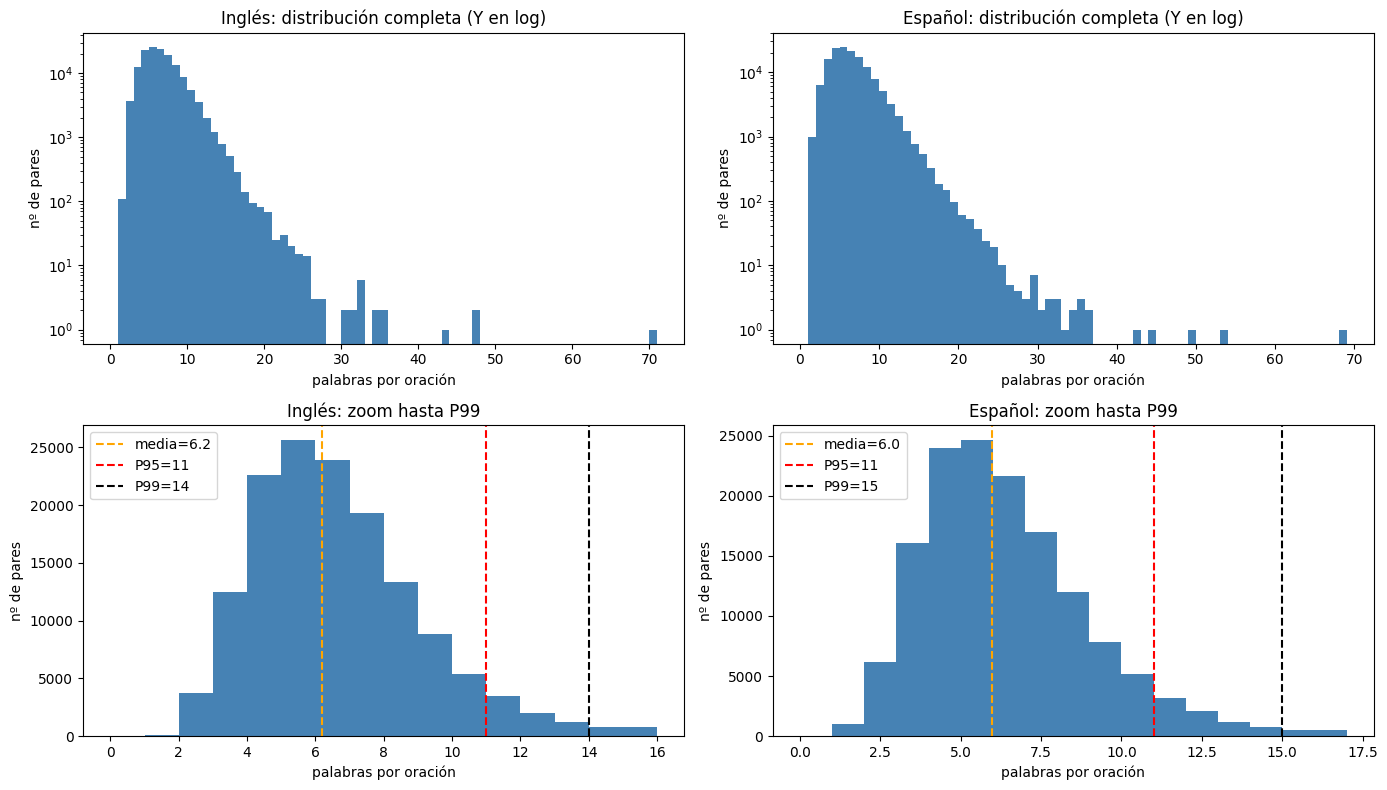


Cobertura acumulada (tokens estimados, sin contar <SOS>/<EOS>):


,L,EN ≤ L (%),ES ≤ L (%),AMBOS ≤ L (%)
0,10,89.12,88.93,85.71
1,15,98.77,98.65,98.25
2,20,99.80,99.76,99.71
3,25,99.95,99.94,99.92
4,30,99.98,99.98,99.98
5,40,100.00,100.00,100.00
6,50,100.00,100.00,100.00



5 pares más largos (por tokens de español):


,english,spanish,english_toks,spanish_toks
144214,"One day, I woke up to find that God had put hair on my face. I shaved it off. The next day, I found that God had put...","Un día, me desperté y vi que Dios me había puesto pelo en la cara. Me lo afeité. Al día siguiente, vi que Dios me lo...",80,78
144213,It may be impossible to get a completely error-free corpus due to the nature of this kind of collaborative effort. H...,Puede que sea imposible obtener un corpus completamente libre de errores debido a la naturaleza de este tipo de esfu...,53,57
144212,"If you want to sound like a native speaker, you must be willing to practice saying the same sentence over and over i...","Si quieres sonar como un hablante nativo, debes estar dispuesto a practicar diciendo la misma frase una y otra vez d...",49,51
144211,"Since there are usually multiple websites on any given topic, I usually just click the back button when I arrive on ...","Como suele haber varias páginas web sobre cualquier tema, normalmente sólo le doy al botón de retroceso cuando entro...",48,47
144206,"In 1969, Roger Miller recorded a song called ""You Don't Want My Love."" Today, this song is better known as ""In the S...","En 1969, Roger Miller grabó una canción llamada ""Tú no quieres mi amor"". Hoy, esta canción es más conocida como ""En ...",44,44


In [ ]:
# =========================
# 3. LONGITUD DE LAS ORACIONES
# =========================
df = df_raw.copy()   # df_raw permanece intacto

# (a) Palabras separadas por espacio
df["english_words"] = df["english"].str.split().str.len()
df["spanish_words"] = df["spanish"].str.split().str.len()

# (b) Tokens estimados: palabra (con apóstrofes internos) o signo suelto
TOK_RE = re.compile(r"\w+(?:'\w+)*|[^\w\s]")
df["english_toks"] = df["english"].map(lambda s: len(TOK_RE.findall(s)))
df["spanish_toks"] = df["spanish"].map(lambda s: len(TOK_RE.findall(s)))

# --- Tabla de estadísticos ---
cols = ["english_words", "spanish_words", "english_toks", "spanish_toks"]
pcts = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
stats = pd.DataFrame({
    c: {
        "min": df[c].min(), "max": df[c].max(),
        "media": df[c].mean(), "mediana": df[c].median(), "std": df[c].std(),
        **{f"P{int(p*100)}": df[c].quantile(p) for p in pcts},
        "P99.9": df[c].quantile(0.999),
    } for c in cols
}).round(2)
print("Estadísticos de longitud:")
display(stats)

# --- Histogramas: completo (eje Y log) y zoom hasta P99 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for j, (lang, col) in enumerate([("Inglés", "english_words"), ("Español", "spanish_words")]):
    x = df[col]
    p95, p99 = x.quantile(0.95), x.quantile(0.99)
    # completo, escala log
    axes[0, j].hist(x, bins=range(0, x.max() + 2), color="steelblue")
    axes[0, j].set_yscale("log")
    axes[0, j].set_title(f"{lang}: distribución completa (Y en log)")
    # zoom
    axes[1, j].hist(x, bins=range(0, int(p99) + 3), color="steelblue")
    axes[1, j].axvline(x.mean(), color="orange", ls="--", label=f"media={x.mean():.1f}")
    axes[1, j].axvline(p95, color="red", ls="--", label=f"P95={p95:.0f}")
    axes[1, j].axvline(p99, color="black", ls="--", label=f"P99={p99:.0f}")
    axes[1, j].set_title(f"{lang}: zoom hasta P99")
    axes[1, j].legend()
    for i in range(2):
        axes[i, j].set_xlabel("palabras por oración"); axes[i, j].set_ylabel("nº de pares")
plt.tight_layout(); plt.show()

# --- Cobertura acumulada: ¿qué % de pares se conserva si limitamos a L? (tokens estimados) ---
both_max = df[["english_toks", "spanish_toks"]].max(axis=1)   # un par se conserva si AMBOS lados caben
cover = pd.DataFrame({
    "L": [10, 15, 20, 25, 30, 40, 50],
})
cover["EN ≤ L (%)"] = [(df["english_toks"] <= L).mean() * 100 for L in cover["L"]]
cover["ES ≤ L (%)"] = [(df["spanish_toks"] <= L).mean() * 100 for L in cover["L"]]
cover["AMBOS ≤ L (%)"] = [(both_max <= L).mean() * 100 for L in cover["L"]]
print("\nCobertura acumulada (tokens estimados, sin contar <SOS>/<EOS>):")
display(cover.round(2))

# --- Ejemplos de la cola larga ---
print("\n5 pares más largos (por tokens de español):")
display(df.nlargest(5, "spanish_toks")[["english", "spanish", "english_toks", "spanish_toks"]])

## 4. Puntuación
Regla: **detectar → contar → analizar → decidir**. Aquí solo detectamos y contamos; no se elimina nada.

In [ ]:
# =========================
# 4. PUNTUACIÓN
# =========================
import unicodedata

TARGET = list(".,?!¿¡:;'\"-()")

def char_stats(series):
    total, rows = collections.Counter(), collections.Counter()
    for s in series:
        total.update(s)
        rows.update(set(s))
    return total, rows

en_tot, en_rows = char_stats(df["english"])
es_tot, es_rows = char_stats(df["spanish"])

def build_table(chars):
    out = []
    for ch in chars:
        out.append({
            "char": ch,
            "nombre": unicodedata.name(ch, "?"),
            "EN_total": en_tot[ch], "EN_filas": en_rows[ch], "EN_%filas": en_rows[ch] / N * 100,
            "ES_total": es_tot[ch], "ES_filas": es_rows[ch], "ES_%filas": es_rows[ch] / N * 100,
        })
    return pd.DataFrame(out).round(2)

print("=== 4.1 Signos pedidos ===")
display(build_table(TARGET))

# Otros símbolos presentes: ni letra, ni dígito, ni espacio, ni los TARGET
all_chars = set(en_tot) | set(es_tot)
others = [c for c in all_chars if not c.isalnum() and not c.isspace() and c not in TARGET]
others.sort(key=lambda c: -(en_rows[c] + es_rows[c]))
print(f"\n=== 4.2 Otros símbolos no alfanuméricos presentes: {len(others)} distintos (top 30 por nº de filas) ===")
display(build_table(others[:30]))

# --- 4.3 ¿Cómo terminan las oraciones? ---
print("\n=== 4.3 Último carácter de cada oración (top 8) ===")
for name, s in [("english", df["english"]), ("spanish", df["spanish"])]:
    last = s.str[-1]
    print(f"\n{name}:")
    print((last.value_counts().head(8) / N * 100).round(2).astype(str).add(" %").to_string())

# --- 4.4 Consistencia ¿ ¡ con ? ! ---
print("\n=== 4.4 Consistencia de signos de apertura en español ===")
for open_c, close_c in [("¿", "?"), ("¡", "!")]:
    en_has = df["english"].str.contains(re.escape(close_c))
    es_open = df["spanish"].str.contains(re.escape(open_c))
    es_close = df["spanish"].str.contains(re.escape(close_c))
    print(f"\n'{close_c}' en inglés  vs  '{open_c}' en español:")
    display(pd.crosstab(en_has.rename(f"EN tiene {close_c}"), es_open.rename(f"ES tiene {open_c}")))
    print(f"ES tiene '{close_c}' pero NO '{open_c}': {(es_close & ~es_open).sum():,}")
    print(f"ES tiene '{open_c}' pero NO '{close_c}': {(es_open & ~es_close).sum():,}")

print("\nEjemplos: ES con '?' pero sin '¿'")
display(df[df["spanish"].str.contains(r"\?") & ~df["spanish"].str.contains("¿")][["english", "spanish"]].sample(8, random_state=SEED))

=== 4.1 Signos pedidos ===


,char,nombre,EN_total,EN_filas,EN_%filas,ES_total,ES_filas,ES_%filas
0,.,FULL STOP,124421,123267,85.47,123746,122834,85.17
1,",",COMMA,8631,8191,5.68,8936,8493,5.89
2,?,QUESTION MARK,20355,20328,14.10,20386,20352,14.11
3,!,EXCLAMATION MARK,1110,1088,0.75,1469,1436,1.00
4,¿,INVERTED QUESTION MARK,0,0,0.00,20379,20345,14.11
5,¡,INVERTED EXCLAMATION MARK,0,0,0.00,1468,1435,1.00
6,:,COLON,262,260,0.18,155,153,0.11
7,;,SEMICOLON,10,10,0.01,30,30,0.02
8,',APOSTROPHE,46425,43089,29.88,24,13,0.01
9,"""",QUOTATION MARK,1204,348,0.24,1018,306,0.21



=== 4.2 Otros símbolos no alfanuméricos presentes: 15 distintos (top 30 por nº de filas) ===


,char,nombre,EN_total,EN_filas,EN_%filas,ES_total,ES_filas,ES_%filas
0,%,PERCENT SIGN,33,31,0.02,33,31,0.02
1,»,RIGHT-POINTING DOUBLE ANGLE QUOTATION MARK,0,0,0.00,87,46,0.03
2,«,LEFT-POINTING DOUBLE ANGLE QUOTATION MARK,0,0,0.00,87,46,0.03
3,$,DOLLAR SIGN,29,29,0.02,13,13,0.01
4,’,RIGHT SINGLE QUOTATION MARK,22,21,0.01,0,0,0.00
5,€,EURO SIGN,2,2,0.00,4,4,0.00
6,/,SOLIDUS,3,3,0.00,2,2,0.00
7,&,AMPERSAND,1,1,0.00,2,2,0.00
8,—,EM DASH,0,0,0.00,6,3,0.00
9,+,PLUS SIGN,2,1,0.00,3,2,0.00



=== 4.3 Último carácter de cada oración (top 8) ===

english:
english
.    85.18 %
?    13.92 %
!      0.7 %
"      0.2 %

spanish:
spanish
.    84.95 %
?    13.93 %
!     0.91 %
"     0.12 %
»     0.03 %
o     0.01 %
e     0.01 %
s     0.01 %

=== 4.4 Consistencia de signos de apertura en español ===

'?' en inglés  vs  '¿' en español:


ES tiene ¿,False,True
EN tiene ?,,
False,123846,41
True,24,20304


ES tiene '?' pero NO '¿': 8
ES tiene '¿' pero NO '?': 1

'!' en inglés  vs  '¡' en español:


ES tiene ¡,False,True
EN tiene !,,
False,142683,444
True,97,991


ES tiene '!' pero NO '¡': 2
ES tiene '¡' pero NO '!': 1

Ejemplos: ES con '?' pero sin '¿'


,english,spanish
20695,Has Tom called yet?,Llamó Tom?
112152,Is there any chance that he'll recover?,Hay alguna posibilidad de que se recupere?
9721,Can I pay later?,Puedo pagar más tarde?
116122,Would you please explain it more simply?,"Podrías, por favor, explicarlo más simple?"
39215,Can you use a computer?,Puedes usar una computadora?
107887,Are you the one who called the police?,Eres uno de los que llamó a la policía?
96614,"Tom is building a house, isn't he?","Tom está construyendo una casa, verdad?"
113442,What have you got there in your pocket?,Qué tiene usted ahí en el bolsillo?


## 5. Caracteres inusuales
Definimos "esperado" por idioma: inglés = letras ASCII + dígitos + espacio + puntuación de la sección 4;
español = lo mismo + `áéíóúüñÁÉÍÓÚÜÑ`. **Todo lo demás es inusual**: se cuenta, se muestra en contexto y solo se elimina si hay justificación.

In [ ]:
# =========================
# 5. CARACTERES INUSUALES
# =========================
import string
pd.set_option("display.max_rows", 120)

ES_LETTERS = "áéíóúüñÁÉÍÓÚÜÑ"
BASE_EN = set(string.ascii_letters + string.digits + " " + "".join(TARGET))
BASE_ES = BASE_EN | set(ES_LETTERS)

def unusual_table(tot, rows, base, lang):
    recs = [{
        "lang": lang, "char": ch, "repr": repr(ch), "codepoint": f"U+{ord(ch):04X}",
        "nombre": unicodedata.name(ch, "?"), "categoria": unicodedata.category(ch),
        "total": tot[ch], "filas": rows[ch],
    } for ch in tot if ch not in base]
    return pd.DataFrame(recs)

unus = pd.concat([
    unusual_table(en_tot, en_rows, BASE_EN, "EN"),
    unusual_table(es_tot, es_rows, BASE_ES, "ES"),
]).sort_values(["lang", "filas"], ascending=[True, False]).reset_index(drop=True)

print("=== 5.1 Inventario de caracteres inusuales (fuera del conjunto esperado) ===")
print(f"Caracteres distintos inusuales: EN={ (unus.lang=='EN').sum() } | ES={ (unus.lang=='ES').sum() }")
display(unus)

# --- 5.2 Contexto: 2 ejemplos por carácter inusual (repr para ver lo invisible) ---
def show_context(ch, col, n=2, w=35):
    hits = df[df[col].str.contains(re.escape(ch), regex=True)]
    for idx, row in hits.sample(min(n, len(hits)), random_state=SEED).iterrows():
        s = row[col]; pos = s.index(ch)
        print(f"   [{idx}] ...{s[max(0, pos-w):pos+w+1]!r}...")

print("\n=== 5.2 Contexto de cada carácter inusual (top 25 por idioma) ===")
for lang, col in [("EN", "english"), ("ES", "spanish")]:
    print(f"\n--- {lang} ---")
    for _, r in unus[unus.lang == lang].head(25).iterrows():
        print(f"{r['repr']} {r['codepoint']} {r['nombre']} ({r['filas']} filas)")
        show_context(r["char"], col)

# --- 5.3 Dígitos ---
print("\n=== 5.3 Dígitos ===")
for name, s in [("english", df["english"]), ("spanish", df["spanish"])]:
    has = s.str.contains(r"\d")
    nums = s.str.findall(r"\d+(?:[.,:]\d+)*").explode().dropna()
    print(f"{name}: filas con dígitos = {has.sum():,} ({has.mean()*100:.2f}%) | números distintos = {nums.nunique():,}")
    print("   top 10 números:", nums.value_counts().head(10).to_dict())

# --- 5.4 Oraciones sin puntuación final ---
print("\n=== 5.4 Oraciones que NO terminan en . ? ! ===")
END = set('.?!')
for name, col in [("english", "english"), ("spanish", "spanish")]:
    no_end = ~df[col].str[-1].isin(END)
    print(f"{name}: {no_end.sum():,} filas ({no_end.mean()*100:.2f}%)")
    display(df[no_end][["english", "spanish"]].sample(min(8, no_end.sum()), random_state=SEED))

=== 5.1 Inventario de caracteres inusuales (fuera del conjunto esperado) ===
Caracteres distintos inusuales: EN=18 | ES=19


,lang,char,repr,codepoint,nombre,categoria,total,filas
0,EN,%,'%',U+0025,PERCENT SIGN,Po,33,31
1,EN,$,'$',U+0024,DOLLAR SIGN,Sc,29,29
2,EN,’,'’',U+2019,RIGHT SINGLE QUOTATION MARK,Pf,22,21
3,EN,é,'é',U+00E9,LATIN SMALL LETTER E WITH ACUTE,Ll,12,12
4,EN,/,'/',U+002F,SOLIDUS,Po,3,3
5,EN,₂,'₂',U+2082,SUBSCRIPT TWO,No,3,3
6,EN,€,'€',U+20AC,EURO SIGN,Sc,2,2
7,EN,°,'°',U+00B0,DEGREE SIGN,So,2,2
8,EN,ü,'ü',U+00FC,LATIN SMALL LETTER U WITH DIAERESIS,Ll,2,2
9,EN,&,'&',U+0026,AMPERSAND,Po,1,1



=== 5.2 Contexto de cada carácter inusual (top 25 por idioma) ===

--- EN ---
'%' U+0025 PERCENT SIGN (31 filas)
   [142943] ...'ceans, lakes, and rivers creates 90% of the water in air.'...
   [130621] ...'of this factory has increased by 20%.'...
'$' U+0024 DOLLAR SIGN (29 filas)
   [138833] ..."apan's exports exceeded imports by $77.8 billion in 1998."...
   [96930] ...'We estimated the damage at $1,000.'...
'’' U+2019 RIGHT SINGLE QUOTATION MARK (21 filas)
   [29243] ...'You’re a show-off.'...
   [131227] ...'Half of the world’s population lives in cities.'...
'é' U+00E9 LATIN SMALL LETTER E WITH ACUTE (12 filas)
   [130583] ...'who is dressed in white is my fiancée.'...
   [122713] ...'We went to the café that I told you about.'...
'/' U+002F SOLIDUS (3 filas)
   [22631] ...'She studies 24 / 7.'...
   [32711] ...'Tom has 20/20 vision.'...
'₂' U+2082 SUBSCRIPT TWO (3 filas)
   [115228] ...'The chemical formula for water is H₂O.'...
   [139142] ...'CO₂ has a lot to do with the so-c

,english,spanish
59871,"""Is he lying?"" ""Obviously.""","""¿Él está mintiendo?"" ""Obviamente."""
142316,"""There's that noise again! Can you hear it?"" ""It's Tom. He's snoring.""","""¡Ahí está ese ruido otra vez! ¿Puedes oírlo?"" ""Es Tom. Está roncando""."
129720,"""Was she a high school student?"" ""Yes, she was.""",«¿Ella era estudiante de instituto?» «Sí.»
138045,"""Does Tom play tennis?"" ""Yes, he plays almost every day.""","""¿Tom juega tenis?"" ""Sí, él juega casi cada día"""
104606,"""Does it taste good?"" ""Yes, it does.""","""¿Está delicioso?"" ""Sí, está delicioso."""
140357,"""What's happening in the cave? I'm curious."" ""I have no idea.""","""¿Qué está ocurriendo en la cueva? Estoy curioso."" ""No tengo ni idea."""
143119,"""It looked like you weren't having much fun."" ""Actually, I had a great time.""","""Parecía que no te estabas divirtiendo mucho"". ""En realidad, la pasé muy bien""."
132339,"""Do you want something to drink?"" ""No, thank you.""","""¿Quieres algo de beber?"" ""No, gracias."""


spanish: 291 filas (0.20%)


,english,spanish
93360,"""How are you?"" ""I can't complain.""",«¿Cómo estás?» «No me puedo quejar.»
142161,"""Yesterday I had a dream about you, Tom."" ""Really? What was I doing?""","""Ayer soñé contigo, Tom."" ""¿En serio? ¿Qué hacía?"""
64828,"""I am a teacher."" ""So am I.""","""Soy maestra."" ""Yo también."""
129152,The last time I saw Tom smile was last October.,La última vez que vi sonreír a Tom fue en octubre
118744,"""Are those your books?"" ""No, they aren't.""","""¿Son estos tus libros?"" ""No."""
112506,"She said to herself, ""I am very happy.""","Ella se dijo a sí misma: ""Soy muy feliz."""
138046,"""Lottery tickets are a waste of money."" ""Not if you win.""","""Los boletos de lotería son una pérdida de dinero."" ""No si ganas."""
110858,"""May I use this telephone?"" ""Go ahead.""","""¿Puedo usar este teléfono?"" ""Adelante."""


## 6. Mayúsculas/minúsculas, contracciones y abreviaturas
Pregunta: ¿qué información lingüística perderíamos al normalizar? Primero medimos; recién después decidimos si hay que pasar a minúsculas o cambiar cómo se tratan las contracciones.

In [ ]:
# =========================
# 6. MAYÚSCULAS, CONTRACCIONES, ABREVIATURAS
# =========================
en_tokens = df["english"].map(TOK_RE.findall)
es_tokens = df["spanish"].map(TOK_RE.findall)
is_word = lambda t: t[0].isalnum()

# ---------- 6.1 Mayúsculas ----------
print("=== 6.1 Mayúsculas ===")
for name, col, toks in [("EN", "english", en_tokens), ("ES", "spanish", es_tokens)]:
    s = df[col]
    first_letter = s.str.extract(r"([^\W\d_])")[0]              # primera letra (salta ¿ ¡ " «)
    print(f"\n[{name}] filas cuya 1ª letra es mayúscula: {first_letter.str.isupper().mean()*100:.2f}%")
    print(f"[{name}] filas TODO EN MAYÚSCULAS (con letras): {s.map(lambda x: x.isupper()).sum():,}")

    cnt_cased = collections.Counter(t for ts in toks for t in ts if is_word(t))
    cnt_lower = collections.Counter()
    variants = collections.defaultdict(collections.Counter)
    for t, c in cnt_cased.items():
        cnt_lower[t.lower()] += c
        variants[t.lower()][t] += c
    multi = {k: v for k, v in variants.items() if len(v) > 1}
    print(f"[{name}] tipos de palabra con mayúsculas: {len(cnt_cased):,} | en minúsculas: {len(cnt_lower):,} "
          f"(reducción {(1-len(cnt_lower)/len(cnt_cased))*100:.1f}%)")
    print(f"[{name}] tipos que existen con más de una forma de capitalización: {len(multi):,}")
    top_multi = sorted(multi.items(), key=lambda kv: -sum(kv[1].values()))[:6]
    print("   ejemplos:", [dict(v) for _, v in top_multi])

    # Capitalizadas a mitad de oración (tras otra palabra): nombres propios
    mid = collections.Counter(
        t for ts in toks for prev, t in zip(ts, ts[1:]) if is_word(prev) and is_word(t) and t[0].isupper()
    )
    print(f"[{name}] top 15 palabras capitalizadas a mitad de oración:", mid.most_common(15))

# ---------- 6.2 Contracciones y posesivos (inglés) ----------
print("\n=== 6.2 Apóstrofes en inglés ===")
apos_types = collections.Counter(t for ts in en_tokens for t in ts if "'" in t)
def suffix(t):
    tl = t.lower()
    if tl.endswith("n't"): return "n't"
    return tl[tl.rfind("'"):]
suf_occ, suf_types = collections.Counter(), collections.defaultdict(set)
for t, c in apos_types.items():
    sfx = suffix(t); suf_occ[sfx] += c; suf_types[sfx].add(t)
print(pd.DataFrame({"ocurrencias": suf_occ, "tipos distintos": {k: len(v) for k, v in suf_types.items()}})
      .sort_values("ocurrencias", ascending=False).head(10).to_string())
print("\nTop 15 tokens con apóstrofe:", apos_types.most_common(15))
print("Tipos con 's (posesivo o 'is'):", len(suf_types["'s"]), "| ¿cuántos aparecen 1 sola vez?:",
      sum(1 for t in suf_types["'s"] if apos_types[t] == 1))

print("\nApóstrofes en ESPAÑOL (13 filas):")
display(df[df["spanish"].str.contains("'")][["english", "spanish"]].head(8))

# ---------- 6.3 Abreviaturas y puntos internos ----------
print("\n=== 6.3 Abreviaturas ===")
ABBR = {"EN": ["Mr.", "Mrs.", "Ms.", "Dr.", "St.", "Prof.", "Jr.", "a.m.", "p.m.", "U.S.", "etc."],
        "ES": ["Sr.", "Sra.", "Srta.", "Dr.", "Dra.", "Ud.", "Uds.", "etc.", "EE. UU.", "a. m.", "p. m."]}
for lang, col in [("EN", "english"), ("ES", "spanish")]:
    res = {a: int(df[col].str.contains(r"(?<!\w)" + re.escape(a), case=False, regex=True).sum()) for a in ABBR[lang]}
    print(f"{lang} filas que contienen cada abreviatura:", res)

for lang, col in [("EN", "english"), ("ES", "spanish")]:
    internal = df[col].str.contains(r"\.\s+\S")           # punto seguido de espacio y más texto
    dotted = df[col].str.contains(r"\b(?:[A-Za-z]\.){2,}")  # tipo U.S., a.m.
    print(f"\n[{lang}] filas con punto interno (pos. multi-oración o abreviatura): {internal.sum():,} ({internal.mean()*100:.2f}%)"
          f" | con siglas tipo U.S.: {dotted.sum():,}")
    display(df[internal][["english", "spanish"]].sample(8, random_state=SEED))

=== 6.1 Mayúsculas ===

[EN] filas cuya 1ª letra es mayúscula: 100.00%
[EN] filas TODO EN MAYÚSCULAS (con letras): 0
[EN] tipos de palabra con mayúsculas: 16,339 | en minúsculas: 14,456 (reducción 11.5%)
[EN] tipos que existen con más de una forma de capitalización: 1,881
   ejemplos: [{'The': 6857, 'the': 26129}, {'to': 31356, 'To': 149}, {'you': 23015, 'You': 4516}, {'a': 20530, 'A': 812}, {'is': 15342, 'Is': 1189}, {'He': 6880, 'he': 3877}]
[EN] top 15 palabras capitalizadas a mitad de oración: [('I', 6611), ('Tom', 5972), ('Mary', 4376), ('French', 1052), ('Boston', 832), ("I'm", 633), ("Tom's", 541), ('English', 448), ("Mary's", 405), ('John', 367), ('Monday', 338), ('TV', 297), ('Australia', 275), ('Japan', 238), ('Christmas', 225)]

[ES] filas cuya 1ª letra es mayúscula: 100.00%
[ES] filas TODO EN MAYÚSCULAS (con letras): 0
[ES] tipos de palabra con mayúsculas: 31,806 | en minúsculas: 28,440 (reducción 10.6%)
[ES] tipos que existen con más de una forma de capitalización: 3,362
 

,english,spanish
5322,Here or to go?,¿P'aquí o pa' llevar?
7320,Come over here.,Ven p'acá.
35928,I work for McDonald's.,Trabajo para McDonald's.
44347,Your O's look like A's.,Tus O's lucen como A's.
75662,He usually goes to McDonald's.,Suele ir al McDonald's.
89728,He was the king of rock-and-roll.,Él era el rey del rock'n'roll.
95911,The British captured Breed's Hill.,Los británicos capturaron la colina de Breed's.
101501,Eating between meals is a bad habit.,'Picotear' entre comidas es un mal hábito.



=== 6.3 Abreviaturas ===
EN filas que contienen cada abreviatura: {'Mr.': 2, 'Mrs.': 1, 'Ms.': 1, 'Dr.': 8, 'St.': 2, 'Prof.': 0, 'Jr.': 1, 'a.m.': 19, 'p.m.': 30, 'U.S.': 10, 'etc.': 1}
ES filas que contienen cada abreviatura: {'Sr.': 1, 'Sra.': 1, 'Srta.': 0, 'Dr.': 6, 'Dra.': 0, 'Ud.': 2, 'Uds.': 1, 'etc.': 3, 'EE. UU.': 3, 'a. m.': 0, 'p. m.': 0}

[EN] filas con punto interno (pos. multi-oración o abreviatura): 1,148 (0.80%) | con siglas tipo U.S.: 64


,english,spanish
87240,Take a break. You could use one.,"Relájate un poco, lo necesitas."
124601,Wait a minute. I want to tell you something.,"Espera un momento, quiero decirte una cosa."
138345,"She isn't kind to him. In fact, she's not kind to anyone.","Ella no es amable con él, de hecho, no es amable con nadie."
111320,He's not my boyfriend. He's my brother.,Él no es mi novio. Es mi hermano.
81948,It's not raining. It's snowing.,No está lloviendo. Está nevando.
117194,I'm double-parked. Could you hurry it up?,Estacioné en doble fila. ¿Podrías apurarte?
112368,"No, thank you. I'm just looking around.","No, gracias. Solo estoy mirando."
134811,Look carefully. I'm going to show you how it's done.,Fíjate bien. Te voy a mostrar cómo se hace.



[ES] filas con punto interno (pos. multi-oración o abreviatura): 825 (0.57%) | con siglas tipo U.S.: 23


,english,spanish
139210,I don't care how much it costs. I'm going to buy it anyway.,No me interesa el costo. Lo voy a comprar de todas maneras.
101620,He doesn't have a job. He's retired.,Él no tiene trabajo. Está retirado.
74942,"""Tom, hurry up."" ""I'm coming!""","""Tom, apúrate"". ""¡Ya voy!"""
99758,That's enough for today. I'm tired.,Es suficiente por hoy. Estoy cansado.
119120,"Hey, this pizza isn't bad. Not bad at all.","Hey, esta pizza no está mal. Nada mal."
124146,The red chair was set apart. It was special.,La silla roja fue puesta aparte. Era especial.
144178,"Honey, I know the budget is tight, but do you think we could splurge a bit and have a night out at a fancy restauran...","Cariño. Sé que el presupuesto es apretado pero, ¿crees que podríamos despilfarrar un poco y salir una noche a un res..."
82498,Tell me about it. I'm all ears.,Cuéntame. Soy todo oídos.


## 7. Relación de longitudes EN/ES
Un par cuyo español es desproporcionadamente más largo o más corto que el inglés puede indicar una traducción incompleta, un desalineamiento o texto añadido. Medimos la relación **antes** de definir ningún límite.

=== 7.1 Correlación y ajuste lineal ===
Pearson  (tokens)  : 0.8677
Spearman (tokens)  : 0.8329
Pearson  (palabras): 0.8572
Recta de regresión: ES_toks ≈ 0.903 * EN_toks + 0.610

=== 7.2 Distribución del ratio ES/EN (tokens) ===
0.001    0.429
0.010    0.571
0.050    0.700
0.250    0.857
0.500    1.000
0.750    1.125
0.950    1.333
0.990    1.600
0.999    2.000
Ratio: mín=0.250  máx=3.167

=== 7.3 Ratio según la longitud del inglés (el ratio es inestable en frases muy cortas) ===


,n,mediana,p5,p95
en_bin,,,,
1-3,3762,1.000,0.667,1.667
4-6,59631,1.000,0.750,1.400
7-10,65130,1.000,0.714,1.286
11-15,13919,0.929,0.714,1.231
16-25,1702,0.947,0.722,1.188
26+,71,1.000,0.821,1.143


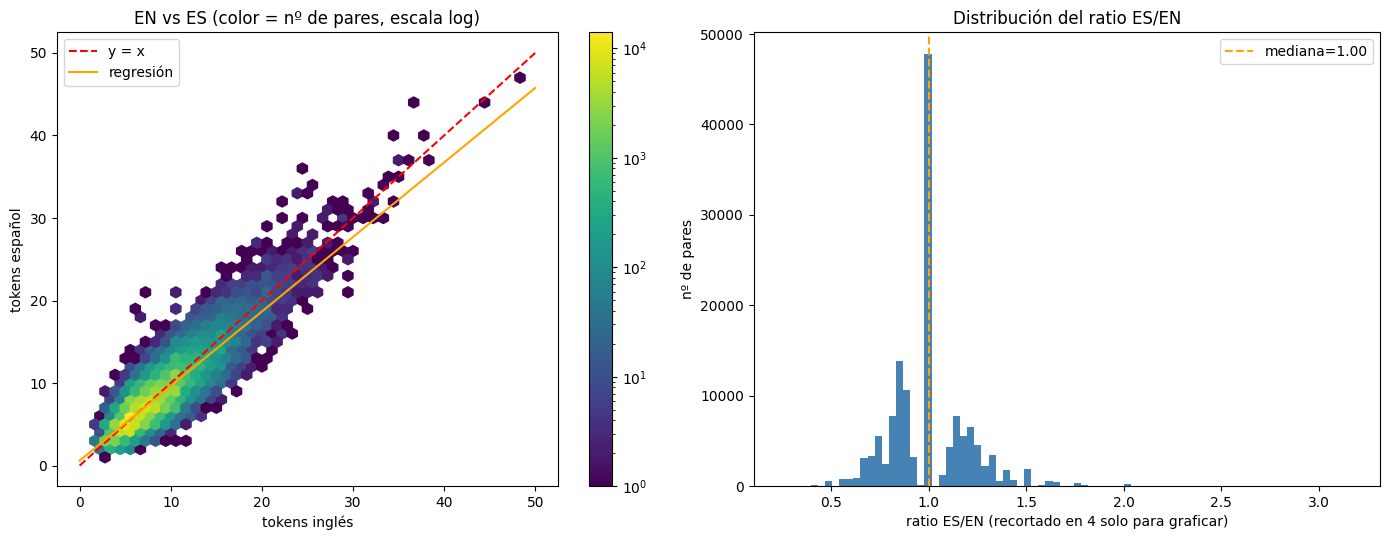


=== 7.4 Español MUCHO MÁS LARGO que el inglés (ratio máximo) ===


,english,spanish,english_toks,spanish_toks,ratio_es_en
64308,What time does class begin?,"¿A qué hora empieza la clase? bien, la clase empieza a las 7 en punto.",6,19,3.17
101229,Absence makes the heart grow fonder.,La ausencia es al amor lo que al fuego el aire: que apaga el pequeño y aviva el grande.,7,21,3.00
23691,Tom's hat blew off.,A Tom se le salió el sombrero con una ráfaga de viento.,5,13,2.60
120990,Animals can't distinguish right from wrong.,Los animales no son capaces de distinguir entre lo que está bien y lo que está mal.,7,18,2.57
122955,Animals cannot distinguish right from wrong.,Los animales no son capaces de distinguir entre lo que está bien y lo que está mal.,7,18,2.57
22631,She studies 24 / 7.,"Ella estudia las veinticuatro horas del día, siete días a la semana.",6,14,2.33
41771,Mind your own business.,No metas tu nariz en los asuntos de los demás.,5,11,2.20
47004,Most boys like baseball.,A la mayoría de los chicos les gusta el béisbol.,5,11,2.20



=== 7.5 Español MUCHO MÁS CORTO que el inglés (ratio mínimo) ===


,english,spanish,english_toks,spanish_toks,ratio_es_en
136712,We managed to bring him around to our way of thinking.,Conseguimos convencerle.,12,3,0.25
117398,Let me say a few words by way of apology.,Permítame excusarme.,11,3,0.27
57340,Let's pull an all-nighter.,Trasnochemos.,7,2,0.29
16485,"Come on, let's go.",Vamos.,6,2,0.33
22254,Keep an eye on him.,Vigilalo.,6,2,0.33
29687,Draw a picture of it.,Dibújenla.,6,2,0.33
29688,Draw a picture of it.,Dibújenlo.,6,2,0.33
29689,Draw a picture of it.,Dibújela.,6,2,0.33


In [ ]:
# =========================
# 7. RELACIÓN DE LONGITUDES EN/ES  (unidad: tokens estimados)
# =========================
x = df["english_toks"]
y = df["spanish_toks"]
df["ratio_es_en"] = y / x.where(x > 0)

print("=== 7.1 Correlación y ajuste lineal ===")
print(f"Pearson  (tokens)  : {x.corr(y):.4f}")
print(f"Spearman (tokens)  : {x.corr(y, method='spearman'):.4f}")
print(f"Pearson  (palabras): {df['english_words'].corr(df['spanish_words']):.4f}")
slope, intercept = np.polyfit(x, y, 1)
print(f"Recta de regresión: ES_toks ≈ {slope:.3f} * EN_toks + {intercept:.3f}")

print("\n=== 7.2 Distribución del ratio ES/EN (tokens) ===")
qs = [0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
print(df["ratio_es_en"].quantile(qs).round(3).to_string())
print(f"Ratio: mín={df['ratio_es_en'].min():.3f}  máx={df['ratio_es_en'].max():.3f}")

print("\n=== 7.3 Ratio según la longitud del inglés (el ratio es inestable en frases muy cortas) ===")
bins = [0, 3, 6, 10, 15, 25, 1000]
labels = ["1-3", "4-6", "7-10", "11-15", "16-25", "26+"]
df["en_bin"] = pd.cut(x, bins=bins, labels=labels)
display(df.groupby("en_bin", observed=True)["ratio_es_en"].agg(
    n="size", mediana="median",
    p5=lambda s: s.quantile(0.05), p95=lambda s: s.quantile(0.95)).round(3))

# --- Gráficos ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
hb = axes[0].hexbin(x, y, gridsize=45, bins="log", mincnt=1, extent=(0, 50, 0, 50), cmap="viridis")
axes[0].plot([0, 50], [0, 50], "r--", label="y = x")
axes[0].plot([0, 50], [intercept, slope * 50 + intercept], "orange", label="regresión")
axes[0].set_xlabel("tokens inglés"); axes[0].set_ylabel("tokens español")
axes[0].set_title("EN vs ES (color = nº de pares, escala log)"); axes[0].legend()
fig.colorbar(hb, ax=axes[0])

axes[1].hist(df["ratio_es_en"].clip(upper=4), bins=80, color="steelblue")
axes[1].axvline(df["ratio_es_en"].median(), color="orange", ls="--", label=f"mediana={df['ratio_es_en'].median():.2f}")
axes[1].set_xlabel("ratio ES/EN (recortado en 4 solo para graficar)"); axes[1].set_ylabel("nº de pares")
axes[1].set_title("Distribución del ratio ES/EN"); axes[1].legend()
plt.tight_layout(); plt.show()

# --- Extremos (solo frases con EN >= 5 tokens para evitar el ruido de frases muy cortas) ---
big = df[x >= 5]
cols = ["english", "spanish", "english_toks", "spanish_toks", "ratio_es_en"]
print("\n=== 7.4 Español MUCHO MÁS LARGO que el inglés (ratio máximo) ===")
display(big.nlargest(8, "ratio_es_en")[cols].round(2))
print("\n=== 7.5 Español MUCHO MÁS CORTO que el inglés (ratio mínimo) ===")
display(big.nsmallest(8, "ratio_es_en")[cols].round(2))

## 8. Frases extremas
Tres preguntas, cada una con datos antes de decidir un límite:
1. **Demasiado cortas**: ¿son ruido o son frases válidas ("Go.", "Hi.")?
2. **Demasiado largas**: ¿qué tipo de texto forma la cola y cuánto cuesta cortarla?
3. **Desbalanceadas**: ¿los ratios extremos son errores o traducciones válidas?

In [ ]:
# =========================
# 8. FRASES EXTREMAS
# =========================
SENT_RE = r'[.?!]+["»”]?(?=\s|$)'     # aproximación: cuenta terminadores de oración
df["n_sent_en"] = df["english"].str.count(SENT_RE)
df["n_sent_es"] = df["spanish"].str.count(SENT_RE)
df["max_toks"] = df[["english_toks", "spanish_toks"]].max(axis=1)

# ---------- 8.1 Demasiado cortas ----------
print("=== 8.1 Frases cortas ===")
short = pd.DataFrame({
    "EN": df["english_toks"].value_counts().sort_index().head(5),
    "ES": df["spanish_toks"].value_counts().sort_index().head(5),
})
short.index.name = "nº de tokens"
display(short)
for lang, col in [("EN", "english"), ("ES", "spanish")]:
    no_letter = ~df[col].str.contains(r"[^\W\d_]")
    print(f"{lang}: filas SIN ninguna letra (solo dígitos/signos): {no_letter.sum():,}")
    if no_letter.sum():
        display(df[no_letter][["english", "spanish"]].head(8))
print("\n10 pares aleatorios con EN <= 2 tokens:")
display(df[df["english_toks"] <= 2][["english", "spanish"]].sample(10, random_state=SEED))

# ---------- 8.2 Demasiado largas ----------
print("\n=== 8.2 Cola larga: ¿qué se pierde con cada límite? (un par se pierde si CUALQUIER lado supera L) ===")
rows = []
for L in [15, 20, 25, 30]:
    sub = df[df["max_toks"] > L]
    rows.append({"L": L, "pares perdidos": len(sub), "% perdido": len(sub) / N * 100,
                 "% con 2+ oraciones (EN)": (sub["n_sent_en"] >= 2).mean() * 100 if len(sub) else 0})
rest = df[df["max_toks"] <= 25]
display(pd.DataFrame(rows).round(2))
print(f"Para comparar: % de pares con 2+ oraciones EN cuando max_toks <= 25: {(rest['n_sent_en'] >= 2).mean()*100:.2f}%")
print(f"Primer índice del archivo con max_toks > 25: {df.index[df['max_toks'] > 25].min():,} de {N:,}")
print("\n10 pares aleatorios con max_toks > 25:")
display(df[df["max_toks"] > 25].sample(10, random_state=SEED)[["english", "spanish", "english_toks", "spanish_toks", "n_sent_en"]])

# ---------- 8.3 Desbalanceados por ratio (solo EN >= 5 tokens) ----------
print("\n=== 8.3 Pares desbalanceados (EN >= 5 tokens) ===")
mid = df[df["english_toks"] >= 5]
print(f"Universo: {len(mid):,} pares")
for thr in [1.6, 2.0]:
    print(f"ratio >= {thr}: {(mid['ratio_es_en'] >= thr).sum():,}")
for thr in [0.6, 0.5, 0.4]:
    print(f"ratio <= {thr}: {(mid['ratio_es_en'] <= thr).sum():,}")

cols = ["english", "spanish", "english_toks", "spanish_toks", "ratio_es_en"]
hi = mid[mid["ratio_es_en"] >= 1.6]
lo = mid[mid["ratio_es_en"] <= 0.5]
print("\nMuestra ALEATORIA (no los peores) con ratio >= 1.6:")
display(hi.sample(min(12, len(hi)), random_state=SEED)[cols].round(2))
print("\nMuestra ALEATORIA con ratio <= 0.5:")
display(lo.sample(min(12, len(lo)), random_state=SEED)[cols].round(2))

# ---------- 8.4 Desajuste en nº de oraciones (pista de texto añadido o perdido) ----------
print("\n=== 8.4 Diferencia |oraciones EN - oraciones ES| ===")
diff = (df["n_sent_en"] - df["n_sent_es"]).abs()
print(diff.value_counts().sort_index().head(8).to_string())
print("\nMuestra de pares con diferencia >= 2:")
big_diff = df[diff >= 2]
display(big_diff.sample(min(10, len(big_diff)), random_state=SEED)[["english", "spanish", "n_sent_en", "n_sent_es"]])

=== 8.1 Frases cortas ===


,EN,ES
nº de tokens,,
1,NaN,1.0
2,108.0,791.0
3,3654.0,4740.0
4,12264.0,14256.0
5,22232.0,22080.0
6,25135.0,NaN


EN: filas SIN ninguna letra (solo dígitos/signos): 0
ES: filas SIN ninguna letra (solo dígitos/signos): 0

10 pares aleatorios con EN <= 2 tokens:


,english,spanish
133,Inhale.,Inhalar.
10,Run!,¡Huye!
4,Go.,Id.
139,Listen.,Escuche.
75,Sorry?,¿Disculpa?
80,Attack!,¡Ataca!
30,Jump.,Salte.
45,Wait.,Esperad.
344,Welcome.,Bienvenidos.
11,Run!,¡Corra!



=== 8.2 Cola larga: ¿qué se pierde con cada límite? (un par se pierde si CUALQUIER lado supera L) ===


...

,english,spanish,english_toks,spanish_toks,ratio_es_en
46697,Is tomato sauce healthy?,¿La salsa de tomate es saludable?,5,8,1.60
52487,Rhinos can attack people.,Los rinocerontes pueden atacar a la gente.,5,8,1.60
19934,Why is milk white?,¿Por qué es blanca la leche?,5,8,1.60
62489,Please come home sometimes.,"Por favor, ven a casa a veces.",5,9,1.80
64559,Words hurt more than fists.,¡Las palabras hacen más daño que los puños!,6,10,1.67
57420,Most children are playful.,La generalidad de los niños son juguetones.,5,8,1.60
27923,Tom and Mary agreed.,Tom y Mary se pusieron de acuerdo.,5,8,1.60
22524,"Quiet down, please.",Haced el favor y bajad la voz.,5,8,1.60
32086,That's all she wrote.,Eso es todo lo que ella escribió.,5,8,1.60
75381,Feeding pigeons is prohibited.,Está prohibido dar de comer a las palomas.,5,9,1.80



Muestra ALEATORIA con ratio <= 0.5:


,english,spanish,english_toks,spanish_toks,ratio_es_en
26932,Let me have a taste.,Déjame probarlo.,6,3,0.50
88943,You ought to do that right away.,Deberías hacerlo inmediatamente.,8,4,0.50
16514,Describe it to me.,Descríbamela.,5,2,0.40
40170,I don't have any money.,Estoy quebrado.,6,3,0.50
17605,I want to come in.,Quiero entrar.,6,3,0.50
66688,I was trying to make amends.,Intentaba disculparme.,7,3,0.43
68298,They seem to be photographs.,Parecen fotografías.,6,3,0.50
17822,I'm on my way out.,Voy saliendo.,6,3,0.50
115449,They seem to be in love with each other.,Ellos parecen estar enamorados.,10,5,0.50
26231,I tried to tell you.,Intenté decírselo.,6,3,0.50



=== 8.4 Diferencia |oraciones EN - oraciones ES| ===
0    143701
1       510
2         4

Muestra de pares con diferencia >= 2:


,english,spanish,n_sent_en,n_sent_es
95464,Mom! Stop! You're embarrassing me.,"¡Mamá, para, me estás avergonzando!",3,1
132865,"My uncle lived in Washington, D. C. for two years.",Mi tío vivió en Washington durante dos años.,3,1
39060,America is rich in oil.,EE. UU. es rico en petróleo.,1,3
111080,Don't ride that horse. He'll throw you.,No monte usted ese caballo porque le tirará a usted,2,0


## 9. Aplicación de filtros y EDA posterior
1. Revisión final de los 61 pares con ratio ≥ 2.0 (para confirmar que no hay filtro por ratio).
2. Normalización de caracteres (transformación, no elimina filas).
3. Filtro de longitud (`MAX_TOKENS_EST = 25`).
4. Tabla antes/después y nuevo EDA.

In [ ]:
# =========================
# 9.0 REVISIÓN: los 61 pares con ratio >= 2.0 (EN >= 5 tokens)
# =========================
rev = df[(df["english_toks"] >= 5) & (df["ratio_es_en"] >= 2.0)]
print(f"Pares con ratio >= 2.0: {len(rev)}")
display(rev[["english", "spanish", "english_toks", "spanish_toks"]].sort_values("english"))

# =========================
# 9.1 NORMALIZACIÓN DE CARACTERES (transforma, no elimina filas)
# =========================
NORMALIZE_MAP = {
    "\u2019": "'", "\u2018": "'",     # apóstrofes tipográficos -> '
    "\u00ab": '"', "\u00bb": '"',     # comillas angulares -> "
    "\u00a0": " ",                    # espacio duro -> espacio
    "\u200b": "",                     # espacio de ancho cero -> se elimina
}
_TRANS = str.maketrans(NORMALIZE_MAP)

def normalize_text(s):
    s = s.translate(_TRANS)
    return re.sub(r"\s{2,}", " ", s).strip()   # el \xa0 dejó un doble espacio (sección 2.2)

df_norm = df_raw.copy()
df_norm["english"] = df_raw["english"].map(normalize_text)
df_norm["spanish"] = df_raw["spanish"].map(normalize_text)

print("\n=== Filas modificadas por cada regla ===")
rows = []
for ch, tgt in NORMALIZE_MAP.items():
    rows.append({"carácter": f"U+{ord(ch):04X} {unicodedata.name(ch)}", "→": repr(tgt),
                 "filas EN": int(df_raw["english"].str.contains(ch, regex=False).sum()),
                 "filas ES": int(df_raw["spanish"].str.contains(ch, regex=False).sum())})
display(pd.DataFrame(rows))
changed = (df_norm["english"] != df_raw["english"]) | (df_norm["spanish"] != df_raw["spanish"])
print(f"Filas con al menos un cambio: {changed.sum():,} ({changed.mean()*100:.3f}%)")
print("Ejemplos antes → después:")
for i in changed[changed].index[:5]:
    print(f"  [{i}] {df_raw.loc[i,'english'][:60]!r} → {df_norm.loc[i,'english'][:60]!r}")
    print(f"       {df_raw.loc[i,'spanish'][:60]!r} → {df_norm.loc[i,'spanish'][:60]!r}")

# ¿La normalización creó duplicados exactos?
dups_after_norm = df_norm.duplicated(subset=["english", "spanish"], keep="first")
print(f"\nDuplicados exactos aparecidos tras normalizar: {dups_after_norm.sum()}")
if dups_after_norm.sum():
    display(df_norm[dups_after_norm][["english", "spanish"]])
df_norm = df_norm[~dups_after_norm]

Pares con ratio >= 2.0: 61


,english,spanish,english_toks,spanish_toks
101229,Absence makes the heart grow fonder.,La ausencia es al amor lo que al fuego el aire: que apaga el pequeño y aviva el grande.,7,21
120990,Animals can't distinguish right from wrong.,Los animales no son capaces de distinguir entre lo que está bien y lo que está mal.,7,18
122955,Animals cannot distinguish right from wrong.,Los animales no son capaces de distinguir entre lo que está bien y lo que está mal.,7,18
93444,Are you still awake? It's bedtime!,"-¿Todavía no te has dormido? -Vamos, que es hora de dormir.",8,17
70137,Children like climbing trees.,A los niños les gusta trepar a los árboles.,5,10
54974,Children like fruit juice.,A los niños les gusta el jugo de fruta.,5,10
54975,Children like gummy bears.,A los niños les gustan las gominolas de ositos.,5,10
65191,Does Tom like cheeseburgers?,¿Le gustan a Tom las hamburguesas de queso?,5,10
39432,Does Tom seem helpless?,¿Te parece que Tom tenga pinta de pusilánime?,5,10
93748,Everyone makes mistakes sometimes.,Todo el mundo comete errores de vez en cuando.,5,10



=== Filas modificadas por cada regla ===


,carácter,→,filas EN,filas ES
0,U+2019 RIGHT SINGLE QUOTATION MARK,"""'""",21,0
1,U+2018 LEFT SINGLE QUOTATION MARK,"""'""",1,0
2,U+00AB LEFT-POINTING DOUBLE ANGLE QUOTATION MARK,"'""'",0,46
3,U+00BB RIGHT-POINTING DOUBLE ANGLE QUOTATION MARK,"'""'",0,46
4,U+00A0 NO-BREAK SPACE,' ',1,1
5,U+200B ZERO WIDTH SPACE,'',0,1


Filas con al menos un cambio: 71 (0.049%)
Ejemplos antes → después:
  [4984] 'Are you a cop?' → 'Are you a cop?'
       '¿Eres «poli»?' → '¿Eres "poli"?'
  [29243] 'You’re a show-off.' → "You're a show-off."
       'Eres una presumida.' → 'Eres una presumida.'
  [34092] 'You’re so arrogant.' → "You're so arrogant."
       'Eres una presumida.' → 'Eres una presumida.'
  [39006] 'You’re so conceited.' → "You're so conceited."
       'Eres una presumida.' → 'Eres una presumida.'
  [49471] '"Objection!" "Sustained!"' → '"Objection!" "Sustained!"'
       '«¡Protesto!» «Se admite.»' → '"¡Protesto!" "Se admite."'

Duplicados exactos aparecidos tras normalizar: 0


In [ ]:
# =========================
# 9.2 FILTRO DE LONGITUD
# =========================
MAX_TOKENS_EST = 25    # de la sección 8.2: 99.92% de pares conservados

df_clean = df_norm.copy()
df_clean["english_toks"]  = df_clean["english"].map(lambda s: len(TOK_RE.findall(s)))
df_clean["spanish_toks"]  = df_clean["spanish"].map(lambda s: len(TOK_RE.findall(s)))
df_clean["english_words"] = df_clean["english"].str.split().str.len()
df_clean["spanish_words"] = df_clean["spanish"].str.split().str.len()

keep = (df_clean["english_toks"] <= MAX_TOKENS_EST) & (df_clean["spanish_toks"] <= MAX_TOKENS_EST)
removed_len = df_clean[~keep]
df_clean = df_clean[keep].reset_index(drop=True)

# =========================
# 9.3 TABLA ANTES / DESPUÉS
# =========================
def summarize(d):
    return {
        "Filas": len(d),
        "Duplicados (EN+ES)": int(d.duplicated(subset=["english", "spanish"]).sum()),
        "Frases inglesas únicas": d["english"].nunique(),
        "Media EN (palabras)": d["english_words"].mean(),
        "Media ES (palabras)": d["spanish_words"].mean(),
        "P95 EN (palabras)": d["english_words"].quantile(0.95),
        "P95 ES (palabras)": d["spanish_words"].quantile(0.95),
        "Máx EN (tokens)": d["english_toks"].max(),
        "Máx ES (tokens)": d["spanish_toks"].max(),
    }

comp = pd.DataFrame({"Antes": summarize(df), "Después": summarize(df_clean)})
print("=== Comparación antes / después ===")
display(comp.round(3))

n_before, n_after = len(df_raw), len(df_clean)
print(f"\nRegistros originales : {n_before:,}")
print(f"Registros eliminados : {n_before - n_after:,}  ({(n_before - n_after)/n_before*100:.3f}%)")
print(f"Registros conservados: {n_after:,}  ({n_after/n_before*100:.3f}%)")
print(f"  - por duplicados tras normalizar: {int(dups_after_norm.sum()):,}")
print(f"  - por longitud (> {MAX_TOKENS_EST} tokens en EN o ES): {len(removed_len):,}")

print("\n8 pares eliminados por longitud (aleatorios):")
display(removed_len.sample(8, random_state=SEED)[["english", "spanish", "english_toks", "spanish_toks"]])

# =========================
# 9.4 EDA NUEVAMENTE (comprobaciones)
# =========================
print("\n=== Comprobaciones sobre df_clean ===")
print("Nulos:", int(df_clean[["english", "spanish"]].isna().sum().sum()),
      "| vacíos:", int(((df_clean["english"] == "") | (df_clean["spanish"] == "")).sum()))
for ch in NORMALIZE_MAP:
    n_ch = int(df_clean["english"].str.contains(ch, regex=False).sum() + df_clean["spanish"].str.contains(ch, regex=False).sum())
    print(f"  filas con U+{ord(ch):04X} restantes: {n_ch}")
print("Puntuación conservada (filas con '?'):", int(df_clean["english"].str.contains(r"\?").sum()))

# Guardar para el reporte y las fases siguientes
os.makedirs("outputs", exist_ok=True)
df_clean[["english", "spanish", "attribution"]].to_csv(
    "outputs/spa_clean.tsv", sep="\t", index=False, quoting=csv.QUOTE_NONE)
comp.round(4).to_csv("outputs/eda_before_after.csv")
print("\nGuardado: outputs/spa_clean.tsv y outputs/eda_before_after.csv")

=== Comparación antes / después ===


,Antes,Después
Filas,144215.000,144106.000
Duplicados (EN+ES),0.000,0.000
Frases inglesas únicas,121487.000,121385.000
Media EN (palabras),6.203,6.189
Media ES (palabras),5.966,5.951
P95 EN (palabras),11.000,11.000
P95 ES (palabras),11.000,11.000
Máx EN (tokens),80.000,25.000
Máx ES (tokens),78.000,25.000



Registros originales : 144,215
Registros eliminados : 109  (0.076%)
Registros conservados: 144,106  (99.924%)
  - por duplicados tras normalizar: 0
  - por longitud (> 25 tokens en EN o ES): 109

8 pares eliminados por longitud (aleatorios):


,english,spanish,english_toks,spanish_toks
144182,"Oh, sure, I studied English in my school days. But it wasn't until two or three years ago that I really started taki...","Oh, por supuesto, estudié inglés en la escuela. Pero no fue hasta hace un par de años o tres que realmente empecé a ...",29,30
144011,"A young boy, who couldn't have been more than five years old, asked Tom how to get to the post office.","Un jovencito, que no podía haber sido de más de cinco años, le preguntó a Tom cómo llegar a la oficina de correos.",24,26
143842,"""When poverty comes in the door, love flies out the window"" is a saying as old as it is sad.","""Cuando la pobreza entra por la puerta, el amor sale volando por la ventana"" es un dicho tan antiguo como es triste.",24,26
144190,"She has a boyfriend she's been going out with since high school, but she feels their relationship is in a rut, so sh...","Ella tiene un novio con el que ha estado saliendo desde el instituto, pero siente que su relación está estancada, as...",28,32
144162,One thing I don't like about the iPad is that you can't easily install apps that aren't available through Apple's Ap...,Una cosa que no me gusta acerca del iPad es que no puedes instalar fácilmente apps que no estén disponibles a través...,23,28
144169,"Singer and actress Selena Gomez started her career at age seven on the children's public television show ""Barney and...",La cantante y actriz Selena Gomez empezó su carrera a los siete años en el espectáculo infantil de la televisión púb...,23,27
144090,"People often lie about what they did on the weekend, so their friends won't realize how boring they really are.",La gente a menudo miente acerca de lo que hicieron el fin de semana para que sus amigos no se den cuenta de lo aburr...,22,30
144131,"Nobody has asked you to agree, but can't you at least accept that there are people who hold different views from you?","Nadie te ha pedido que estés de acuerdo, pero ¿no puedes aceptar al menos que hay gente que tiene un punto de vista ...",24,29



=== Comprobaciones sobre df_clean ===
Nulos: 0 | vacíos: 0
  filas con U+2019 restantes: 0
  filas con U+2018 restantes: 0
  filas con U+00AB restantes: 0
  filas con U+00BB restantes: 0
  filas con U+00A0 restantes: 0
  filas con U+200B restantes: 0
Puntuación conservada (filas con '?'): 20318

Guardado: outputs/spa_clean.tsv y outputs/eda_before_after.csv


In [ ]:
# =========================
# CIERRE DEL EDA: LOG PARA EL REPORTE + DESCARGA
# =========================
import json, shutil

eda_log = {
    "dataset": {
        "fuente": "ManyThings/Tatoeba spa-eng.zip (spa.txt)",
        "origen_de_descarga": DOWNLOAD_SOURCE,
        "pares_crudos": int(N),
    },
    "calidad": {
        "nulos": int(df_raw.isna().sum().sum()),
        "vacios": int(empty_en.sum() + empty_es.sum()),
        "duplicados_exactos_en_es": int(dup_pair.sum()),
        "ingles_unicos": int(len(g)),
        "ingles_con_2plus_traducciones": int((g >= 2).sum()),
        "filas_en_ingles_con_2plus_traducciones": int(df_raw["english"].map(g).ge(2).sum()),
        "max_traducciones_de_un_ingles": int(g.max()),
    },
    "longitud_estadisticos": stats.to_dict(),
    "cobertura_por_limite": cover.round(3).to_dict("records"),
    "relacion_en_es": {
        "pearson_tokens": float(x.corr(y)),
        "pendiente": float(slope),
        "ratio_percentiles": df["ratio_es_en"].quantile(qs).round(3).to_dict(),
    },
    "normalizacion": {"reglas": {f"U+{ord(k):04X}": v for k, v in NORMALIZE_MAP.items()},
                      "filas_modificadas": int(changed.sum())},
    "filtro_longitud": {"MAX_TOKENS_EST": MAX_TOKENS_EST, "filas_eliminadas": int(len(removed_len))},
    "antes_despues": comp.round(4).to_dict(),
    "filas_originales": int(n_before), "filas_finales": int(n_after),
    "pct_eliminado": round((n_before - n_after) / n_before * 100, 4),
    "pct_conservado": round(n_after / n_before * 100, 4),
    "decisiones": [
        "No se elimina puntuación",
        "No se pasa a minúsculas",
        "No se filtra por ratio EN/ES",
        "No se filtran frases cortas",
        "No se eliminan traducciones múltiples de un mismo inglés",
        "MAX_TOKENS_EST es provisional: se recalcula con el tokenizador final",
    ],
}
with open("outputs/eda_log.json", "w", encoding="utf-8") as f:
    json.dump(eda_log, f, ensure_ascii=False, indent=2,
              default=lambda o: o.item() if hasattr(o, "item") else str(o))

shutil.make_archive("eda_outputs", "zip", "outputs")
print("Creado eda_outputs.zip con:", os.listdir("outputs"))
try:
    from google.colab import files
    files.download("eda_outputs.zip")
except Exception as e:
    print("Descarga manual desde el panel de archivos:", e)

Creado eda_outputs.zip con: ['eda_before_after.csv', 'eda_log.json', 'spa_clean.tsv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# =========================
# GUARDAR EN DRIVE PARA LA SIGUIENTE ETAPA
# =========================
from google.colab import drive
import shutil
drive.mount("/content/drive")

PROJ = "/content/drive/MyDrive/PROYECTO TRADUCTOR"
DATA_OUT = os.path.join(PROJ, "data")
os.makedirs(DATA_OUT, exist_ok=True)

def save_tsv(d, path):
    # escritura manual: el texto contiene comillas y no queremos depender de reglas de CSV
    with open(path, "w", encoding="utf-8", newline="\n") as f:
        for e, s, a in zip(d["english"], d["spanish"], d["attribution"]):
            f.write(f"{e}\t{s}\t{a}\n")

save_tsv(df_norm,  os.path.join(DATA_OUT, "spa_normalized.tsv"))   # normalizado, SIN filtro de longitud
save_tsv(df_clean, os.path.join(DATA_OUT, "spa_clean.tsv"))        # normalizado + filtro provisional (<=25)
shutil.copy("outputs/eda_log.json", DATA_OUT)

print("Contenido de data/:", os.listdir(DATA_OUT))
print(f"spa_normalized: {len(df_norm):,} filas | spa_clean: {len(df_clean):,} filas")

Mounted at /content/drive
Contenido de data/: ['spa_normalized.tsv', 'spa_clean.tsv', 'eda_log.json']
spa_normalized: 144,215 filas | spa_clean: 144,106 filas
